In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv(r"../data/01-raw/listings.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [7]:
df.describe(include="object").T

,count,unique,top,freq
name,48879,47905,Hillside Hotel,18
host_name,48874,11452,Michael,417
neighbourhood_group,48895,5,Manhattan,21661
neighbourhood,48895,221,Williamsburg,3920
room_type,48895,3,Entire home/apt,25409
last_review,38843,1764,2019-06-23,1413


In [8]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

### EDA

In [9]:
# Set Seaborn style for cleaner visuals
sns.set(style="whitegrid")

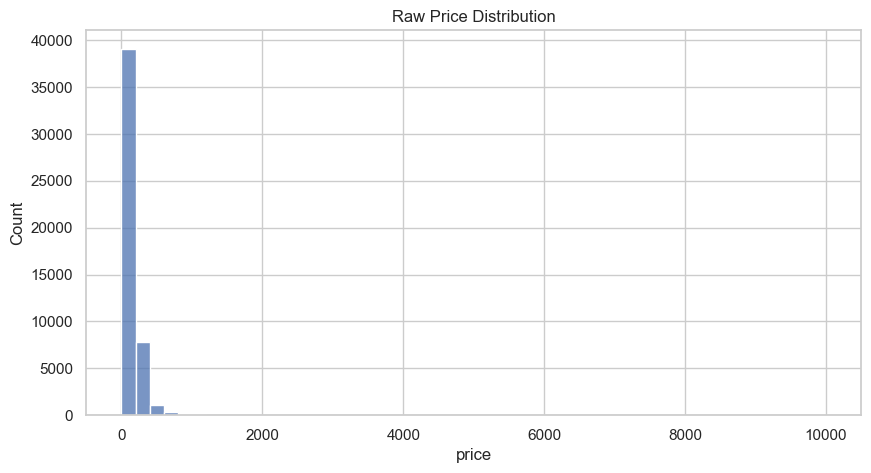

In [10]:
# Visualize raw price distribution to understand skew and outliers
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50)
plt.title("Raw Price Distribution")
plt.show()

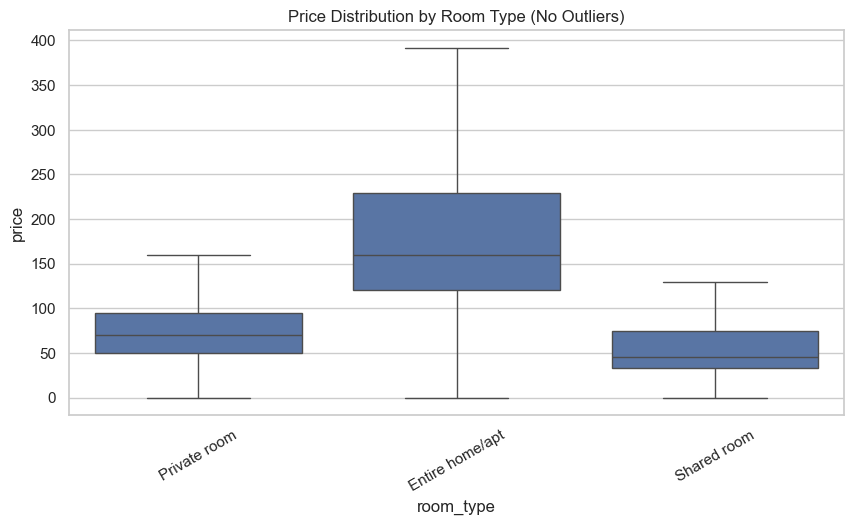

In [12]:
# Compare price distributions across different room types
plt.figure(figsize=(10, 5))
sns.boxplot(x="room_type", y="price", data=df, showfliers=False)

# Rotate labels for readability
plt.xticks(rotation=30)
plt.title("Price Distribution by Room Type (No Outliers)")
plt.show()

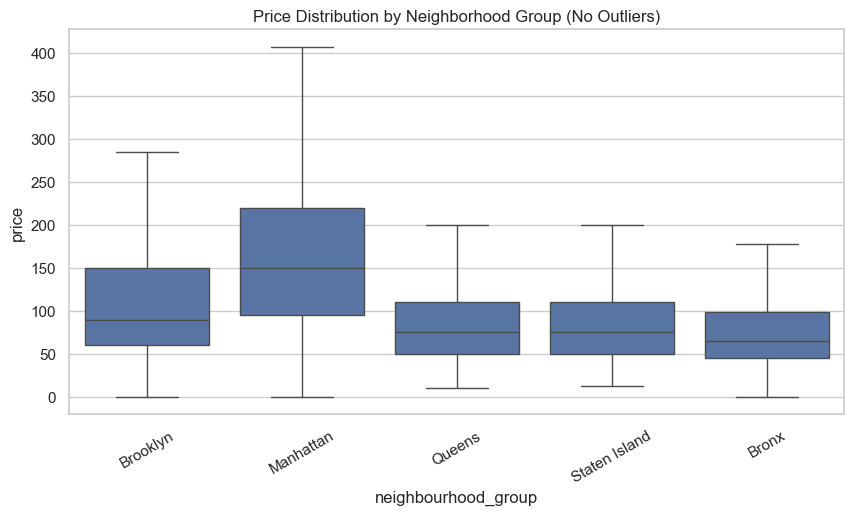

In [13]:
# Analyze how price varies by geographic location (neighborhood group)
plt.figure(figsize=(10, 5))
sns.boxplot(x="neighbourhood_group", y="price", data=df, showfliers=False)

# Rotate labels for readability
plt.xticks(rotation=30)
plt.title("Price Distribution by Neighborhood Group (No Outliers)")
plt.show()

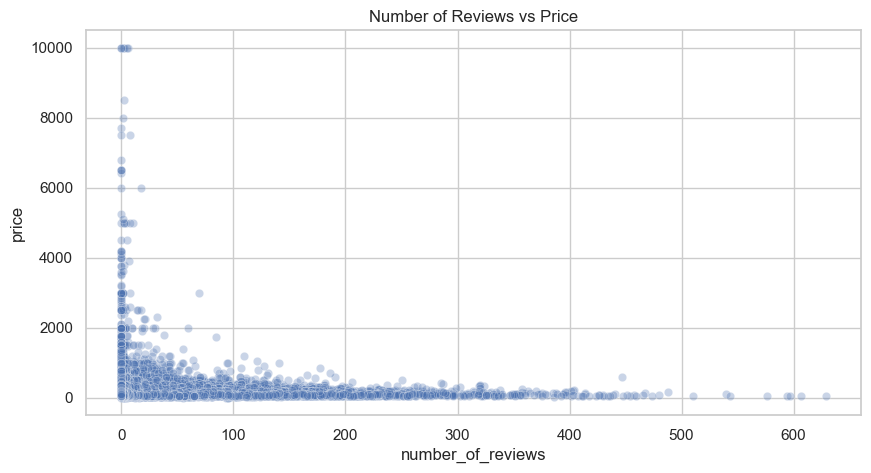

In [14]:
# Explore relationship between demand proxy (reviews) and price
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x="number_of_reviews",
    y="price",
    data=df,
    alpha=0.3  # transparency to handle overlapping points
)

# Title to describe relationship
plt.title("Number of Reviews vs Price")
plt.show()

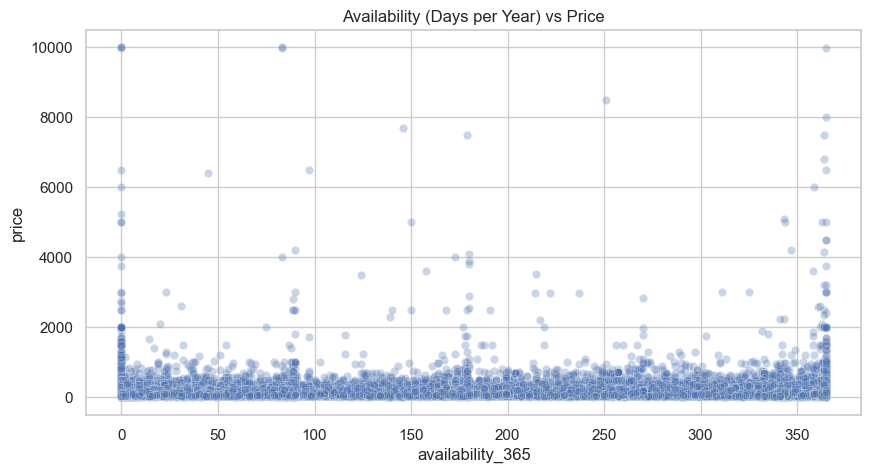

In [15]:
# Explore how availability relates to pricing behavior
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x="availability_365",
    y="price",
    data=df,
    alpha=0.3
)

# Title for interpretation
plt.title("Availability (Days per Year) vs Price")
plt.show()

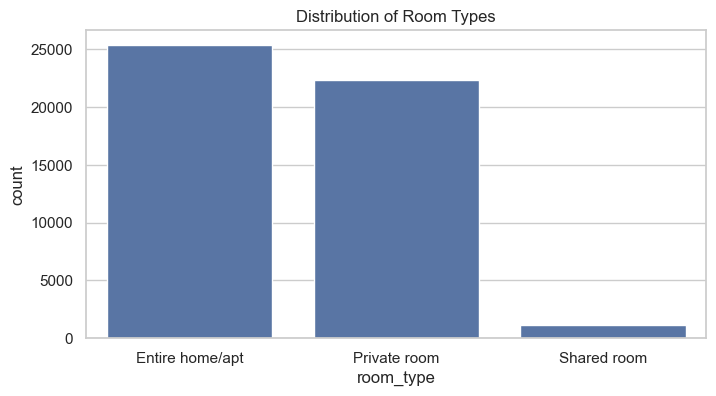

In [16]:
# Count distribution of room types (categorical feature)
plt.figure(figsize=(8, 4))
sns.countplot(x="room_type", data=df, order=df['room_type'].value_counts().index)

# Title for clarity
plt.title("Distribution of Room Types")
plt.show()

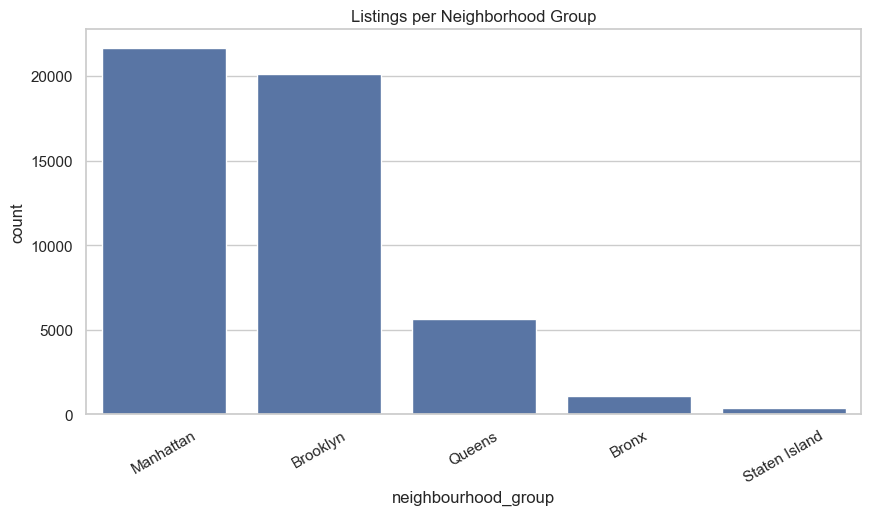

In [17]:
# Count listings by neighborhood group to understand geographic distribution
plt.figure(figsize=(10, 5))
sns.countplot(x="neighbourhood_group", data=df, order=df['neighbourhood_group'].value_counts().index)

# Rotate labels for readability
plt.xticks(rotation=30)
# Title
plt.title("Listings per Neighborhood Group")
plt.show()

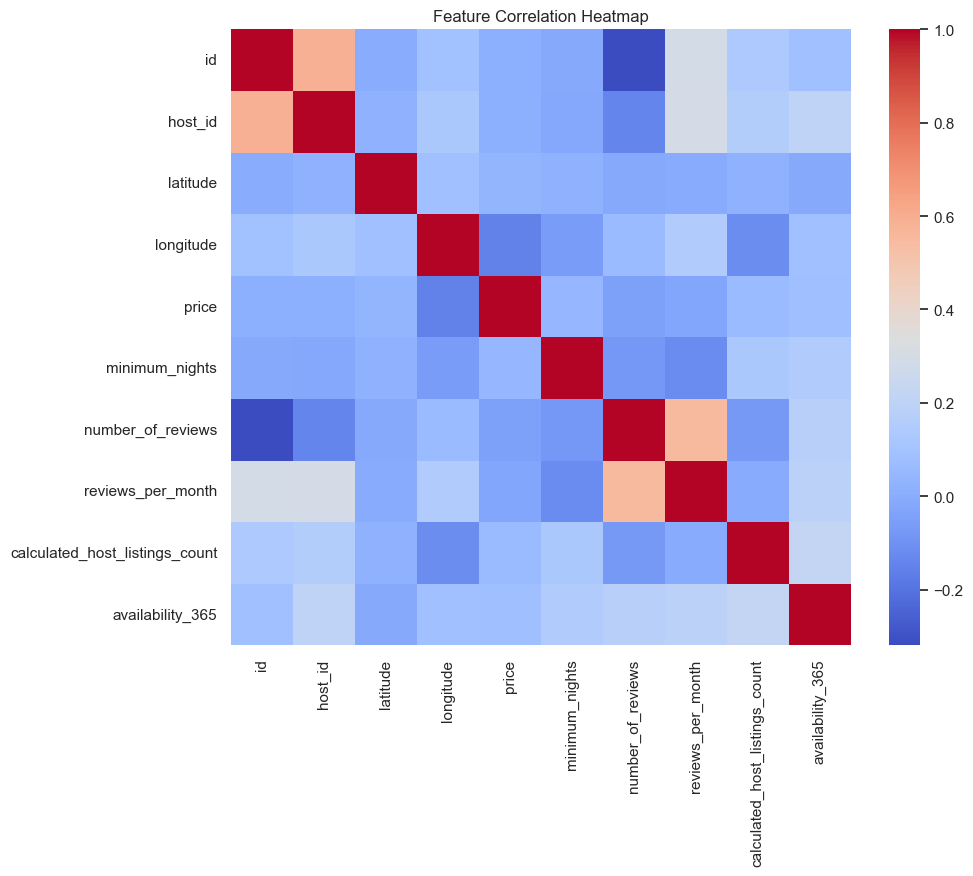

In [18]:
# Compute correlation matrix for numeric features
corr = df.select_dtypes(include="number").corr()

# Visualize correlation matrix using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)

# Title for interpretation
plt.title("Feature Correlation Heatmap")
plt.show()

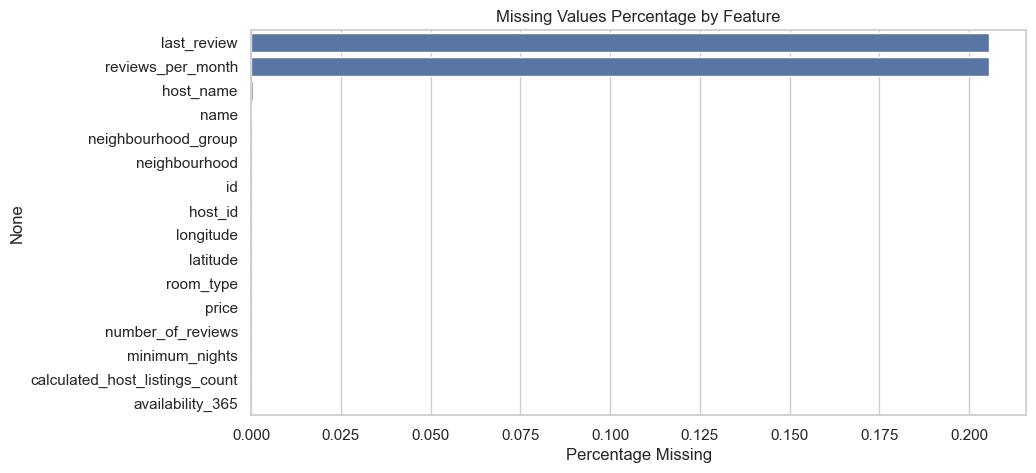

In [19]:
# Calculate percentage of missing values per column
missing_pct = df.isnull().mean().sort_values(ascending=False)

# Visualize missing data distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index)

# Labels for clarity
plt.title("Missing Values Percentage by Feature")
plt.xlabel("Percentage Missing")
plt.show()

In [20]:
df["availability_ratio"] = df["availability_365"] / 365

In [21]:
# Keep relevant columns
columns_to_keep = [
    "id",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "room_type",
    "neighbourhood_group",
    "latitude",
    "longitude"
]

df = df[columns_to_keep].copy()

In [22]:
# Convert price to numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [23]:
# Remove missing or non-positive prices
df = df[df["price"].notna()]
df = df[df["price"] > 0]

In [24]:
# Fill missing values
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [25]:
# Rename columns
df = df.rename(columns={
    "id": "listing_id",
    "neighbourhood_group": "city",
    "calculated_host_listings_count": "host_listing_count"
})

In [26]:
# Create price log feature
df["price_log"] = np.log1p(df["price"])

In [27]:
# Create demand score
df["demand_score"] = df["number_of_reviews"] * df["reviews_per_month"]

In [30]:
# Create availability ratio
df["availability_ratio"] = df["availability_365"] / 365

In [31]:
# Reorder final columns
final_columns = [
    "listing_id",
    "price",
    "price_log",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "host_listing_count",
    "availability_365",
    "availability_ratio",
    "room_type",
    "city",
    "latitude",
    "longitude",
    "demand_score"
]

df = df[final_columns]

In [32]:
# Save cleaned dataset
df.to_csv(r"../data/02-preprocessed/listings_clean.csv", index=False)

In [ ]:
# Plot log-transformed price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50)
plt.title("Price Distribution")
plt.show()

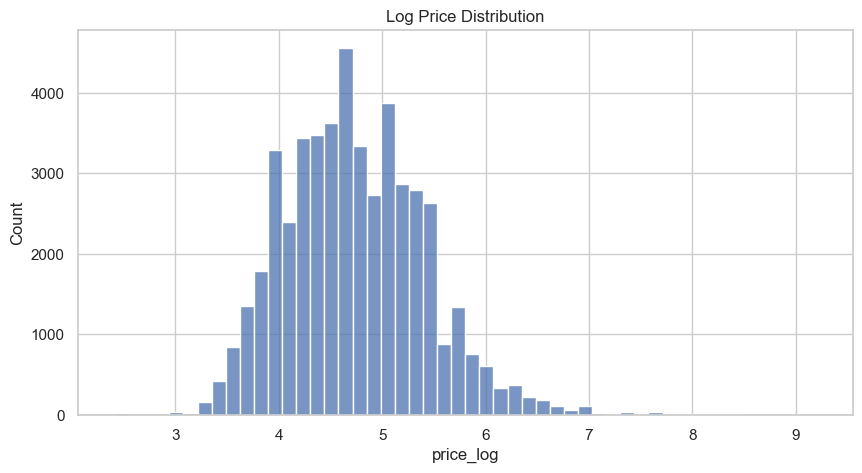

In [33]:
# Plot log-transformed price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["price_log"], bins=50)
plt.title("Log Price Distribution")
plt.show()

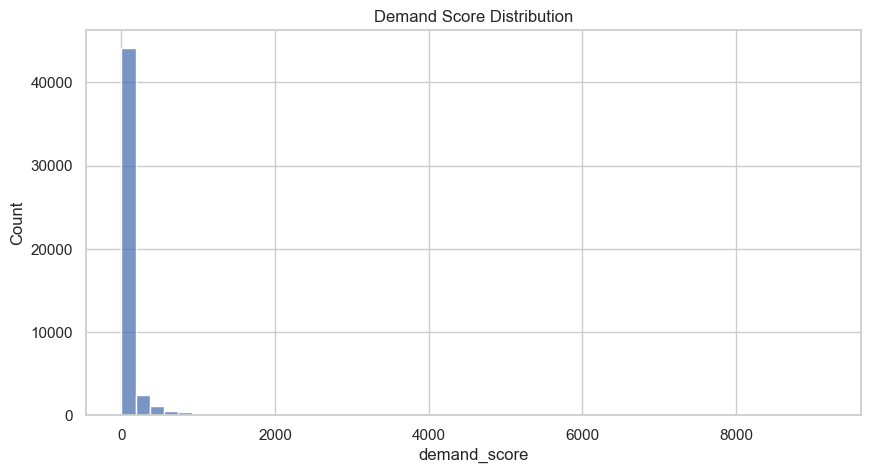

In [34]:
# Plot demand score distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["demand_score"], bins=50)
plt.title("Demand Score Distribution")
plt.show()

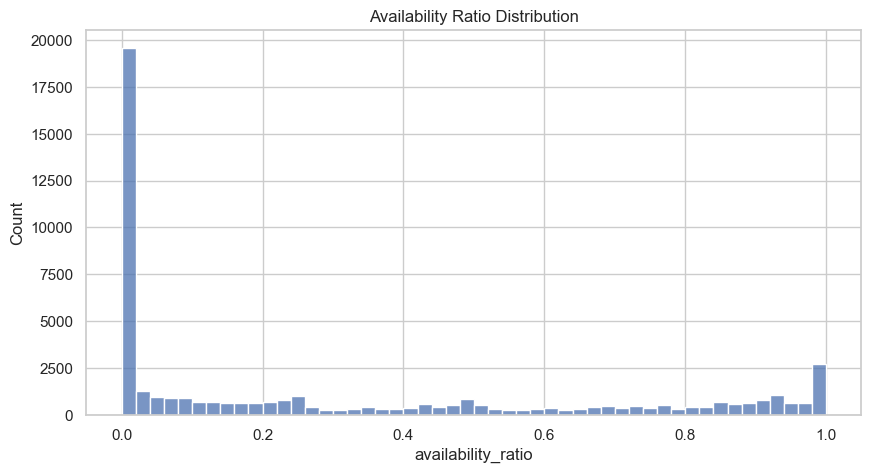

In [35]:
# Plot availability ratio distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["availability_ratio"], bins=50)
plt.title("Availability Ratio Distribution")
plt.show()

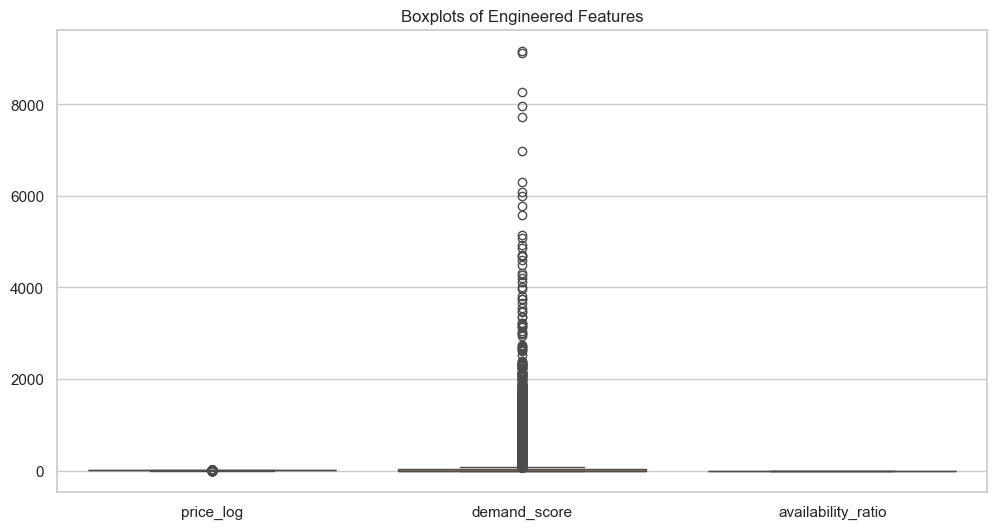

In [36]:
# Plot boxplots for engineered features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["price_log", "demand_score", "availability_ratio"]])
plt.title("Boxplots of Engineered Features")
plt.show()

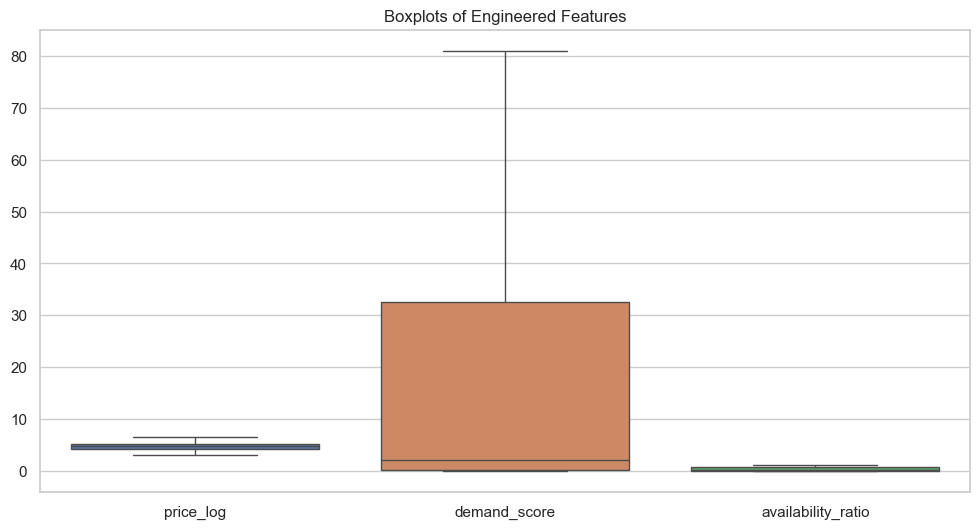

In [37]:
# Plot boxplots for engineered features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["price_log", "demand_score", "availability_ratio"]], showfliers=False)
plt.title("Boxplots of Engineered Features")
plt.show()

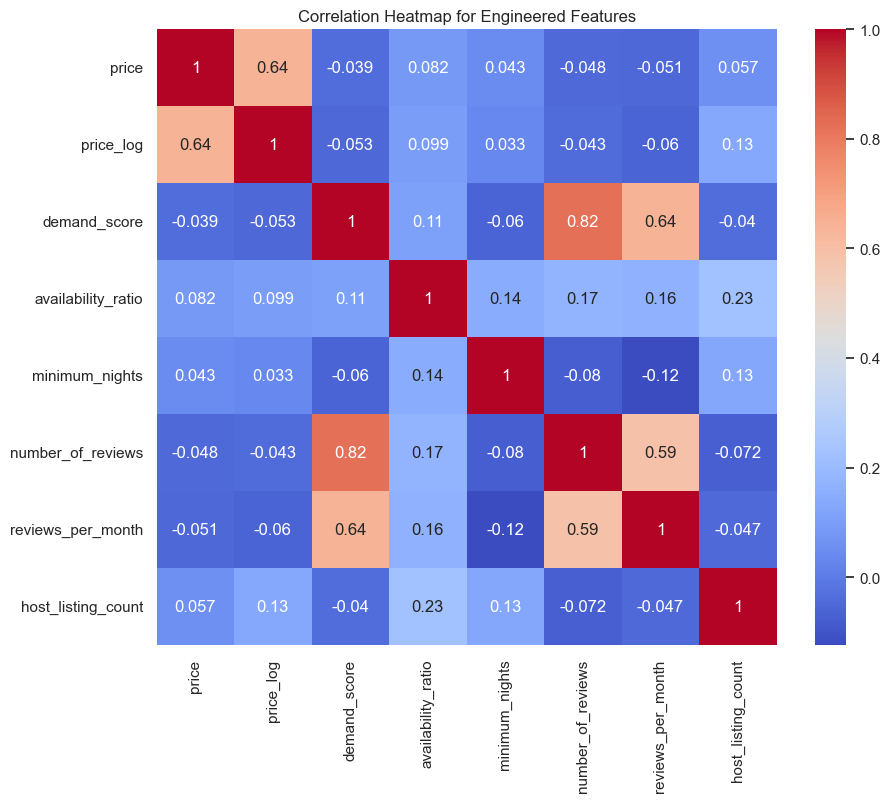

In [38]:
# Plot correlation heatmap for selected numeric features
engineered_corr = df[[
    "price",
    "price_log",
    "demand_score",
    "availability_ratio",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "host_listing_count"
]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(engineered_corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Engineered Features")
plt.show()

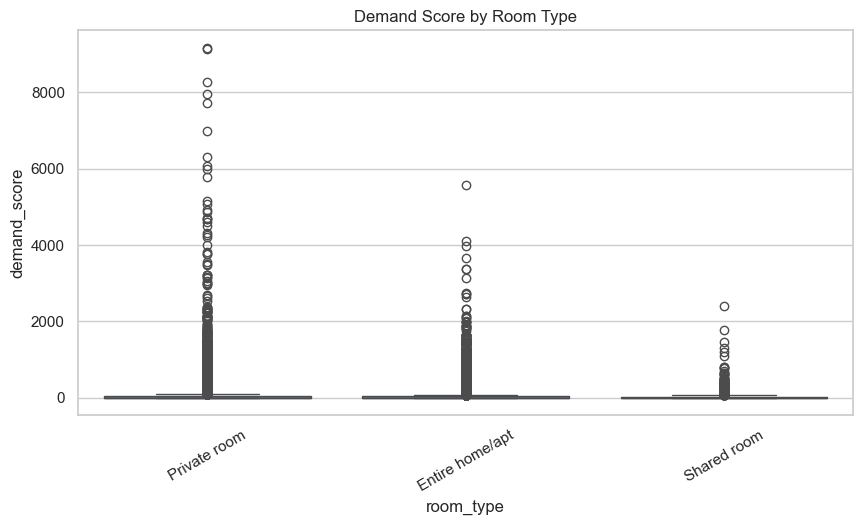

In [39]:
# Compare demand score across room types
plt.figure(figsize=(10, 5))
sns.boxplot(x="room_type", y="demand_score", data=df)
plt.title("Demand Score by Room Type")
plt.xticks(rotation=30)
plt.show()

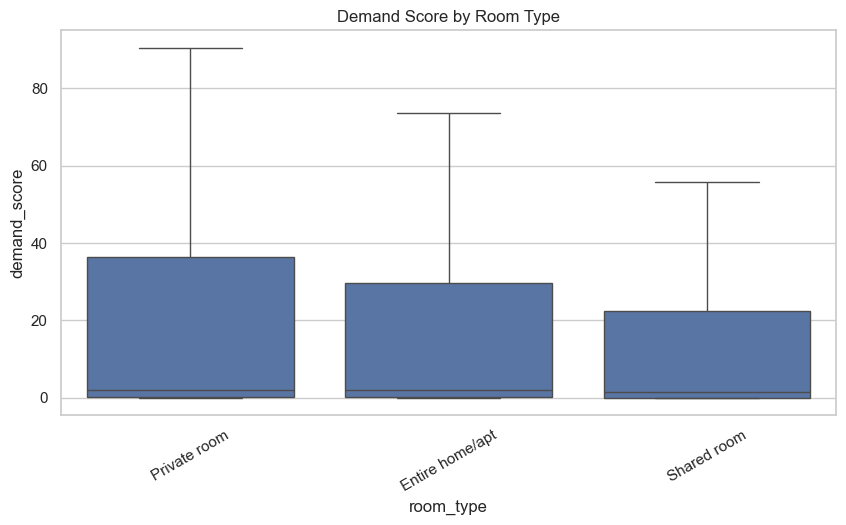

In [40]:
# Compare demand score across room types
plt.figure(figsize=(10, 5))
sns.boxplot(x="room_type", y="demand_score", data=df, showfliers=False)
plt.title("Demand Score by Room Type")
plt.xticks(rotation=30)
plt.show()

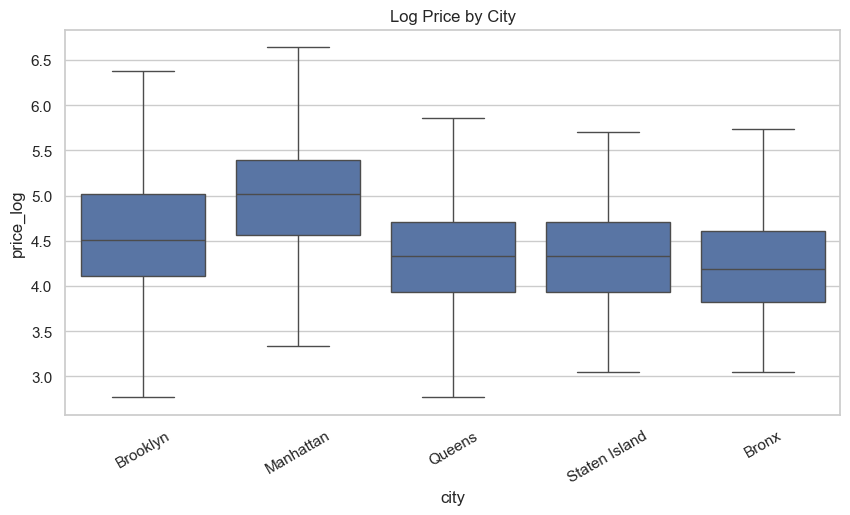

In [42]:
# Compare log price across city groups
plt.figure(figsize=(10, 5))
sns.boxplot(x="city", y="price_log", data=df, showfliers=False)
plt.title("Log Price by City")
plt.xticks(rotation=30)
plt.show()